In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from google.colab import files

uploaded = files.upload()

Saving superstore_final_dataset (1).csv to superstore_final_dataset (1).csv


##LOAD THE DATASET


In [5]:
df = pd.read_csv(
    "superstore_final_dataset (1).csv",
    encoding="latin1"
)

print("Dataset loaded successfully!")

Dataset loaded successfully!


## CHECK DATASET SIZE


In [6]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 9800
Number of columns: 18


##VIEW FIRST 5 ROWS

In [7]:
df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680


##CHECK COLUMN NAMES

In [8]:
print("Column names:")

for column in df.columns:
    print(column)

Column names:
Row_ID
Order_ID
Order_Date
Ship_Date
Ship_Mode
Customer_ID
Customer_Name
Segment
Country
City
State
Postal_Code
Region
Product_ID
Category
Sub_Category
Product_Name
Sales


##CHECK DATA TYPES

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row_ID         9800 non-null   int64  
 1   Order_ID       9800 non-null   object 
 2   Order_Date     9800 non-null   object 
 3   Ship_Date      9800 non-null   object 
 4   Ship_Mode      9800 non-null   object 
 5   Customer_ID    9800 non-null   object 
 6   Customer_Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal_Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product_ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub_Category   9800 non-null   object 
 16  Product_Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

##Check Missing Values

In [11]:
missing_values = df.isnull().sum()

print(missing_values)

Row_ID            0
Order_ID          0
Order_Date        0
Ship_Date         0
Ship_Mode         0
Customer_ID       0
Customer_Name     0
Segment           0
Country           0
City              0
State             0
Postal_Code      11
Region            0
Product_ID        0
Category          0
Sub_Category      0
Product_Name      0
Sales             0
dtype: int64


##COLUMNS WITH MISSING VALUES

In [12]:
missing_values = df.isnull().sum()

print("Columns with missing values:")

print(missing_values[missing_values > 0])

Columns with missing values:
Postal_Code    11
dtype: int64


##CHECK DUPLICATES

In [13]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


##REMOVE DUPLICATES

In [14]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (9800, 18)


In [16]:
df['Order_Date'] = pd.to_datetime(
    df['Order_Date'],
    dayfirst=True
)

print("Order_Date converted successfully!")

Order_Date converted successfully!


In [18]:
df['Ship_Date'] = pd.to_datetime(
    df['Ship_Date'],
    dayfirst=True
)

print("Ship_Date converted successfully!")

Ship_Date converted successfully!


In [19]:
print("Earliest Order Date:", df['Order_Date'].min())
print("Latest Order Date:", df['Order_Date'].max())

Earliest Order Date: 2015-01-03 00:00:00
Latest Order Date: 2018-12-30 00:00:00


In [20]:
df['Year'] = df['Order_Date'].dt.year

df[['Order_Date', 'Year']].head()

,Order_Date,Year
0,2017-11-08,2017
1,2017-11-08,2017
2,2017-06-12,2017
3,2016-10-11,2016
4,2016-10-11,2016


In [21]:
df['Month'] = df['Order_Date'].dt.month

df[['Order_Date', 'Month']].head()

,Order_Date,Month
0,2017-11-08,11
1,2017-11-08,11
2,2017-06-12,6
3,2016-10-11,10
4,2016-10-11,10


In [22]:
df['Month_Name'] = df['Order_Date'].dt.month_name()

df[['Order_Date', 'Month_Name']].head()

,Order_Date,Month_Name
0,2017-11-08,November
1,2017-11-08,November
2,2017-06-12,June
3,2016-10-11,October
4,2016-10-11,October


In [23]:
df['Quarter'] = df['Order_Date'].dt.quarter

df[['Order_Date', 'Quarter']].head()

,Order_Date,Quarter
0,2017-11-08,4
1,2017-11-08,4
2,2017-06-12,2
3,2016-10-11,4
4,2016-10-11,4


In [24]:
df['Year_Month'] = df['Order_Date'].dt.to_period('M')

df[['Order_Date', 'Year_Month']].head()

,Order_Date,Year_Month
0,2017-11-08,2017-11
1,2017-11-08,2017-11
2,2017-06-12,2017-06
3,2016-10-11,2016-10
4,2016-10-11,2016-10


##KPI ANALYSIS

In [25]:
print("Sales data type:", df['Sales'].dtype)
print("Missing Sales:", df['Sales'].isnull().sum())
print("Minimum Sales:", df['Sales'].min())
print("Maximum Sales:", df['Sales'].max())
print("Average Sales:", df['Sales'].mean())

Sales data type: float64
Missing Sales: 0
Minimum Sales: 0.444
Maximum Sales: 22638.48
Average Sales: 230.7690594591837


In [26]:
zero_sales = (df['Sales'] == 0).sum()
negative_sales = (df['Sales'] < 0).sum()

print("Zero Sales:", zero_sales)
print("Negative Sales:", negative_sales)

Zero Sales: 0
Negative Sales: 0


In [27]:
df['Sales'].describe()

,Sales
count,9800.000000
mean,230.769059
std,626.651875
min,0.444000
25%,17.248000
50%,54.490000
75%,210.605000
max,22638.480000


In [28]:
total_revenue = df['Sales'].sum()

print("Total Revenue:", round(total_revenue, 2))

Total Revenue: 2261536.78


In [29]:
total_orders = df['Order_ID'].nunique()

print("Total Orders:", total_orders)

Total Orders: 4922


In [30]:
total_customers = df['Customer_ID'].nunique()

print("Total Customers:", total_customers)

Total Customers: 793


In [31]:
average_order_value = total_revenue / total_orders

print("Average Order Value:", round(average_order_value, 2))

Average Order Value: 459.48


In [32]:
kpi_summary = pd.DataFrame({
    'KPI': [
        'Total Revenue',
        'Total Orders',
        'Total Customers',
        'Average Order Value'
    ],
    'Value': [
        total_revenue,
        total_orders,
        total_customers,
        average_order_value
    ]
})

kpi_summary

,KPI,Value
0,Total Revenue,2.261537e+06
1,Total Orders,4.922000e+03
2,Total Customers,7.930000e+02
3,Average Order Value,4.594752e+02


##TIME ANALYSIS

In [33]:
yearly_sales = df.groupby('Year')['Sales'].sum().reset_index()

yearly_sales

,Year,Sales
0,2015,479856.2081
1,2016,459436.0054
2,2017,600192.5500
3,2018,722052.0192


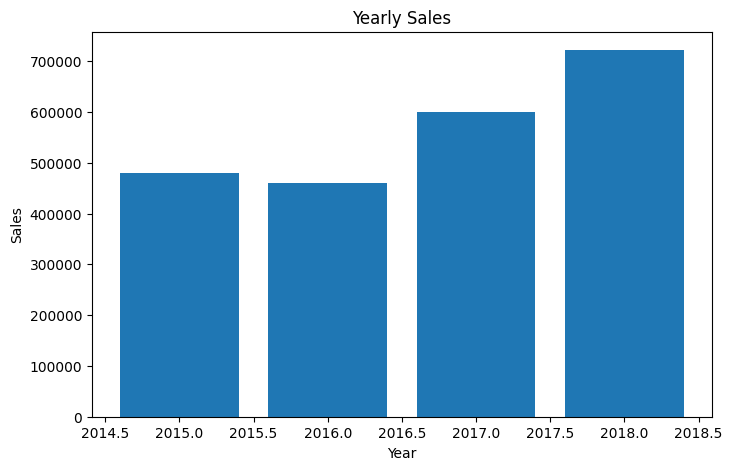

In [34]:
plt.figure(figsize=(8,5))

plt.bar(yearly_sales['Year'], yearly_sales['Sales'])

plt.title('Yearly Sales')
plt.xlabel('Year')
plt.ylabel('Sales')

plt.show()

In [35]:
monthly_sales = df.groupby('Year_Month')['Sales'].sum().reset_index()

monthly_sales

,Year_Month,Sales
0,2015-01,14205.7070
1,2015-02,4519.8920
2,2015-03,55205.7970
3,2015-04,27906.8550
4,2015-05,23644.3030
5,2015-06,34322.9356
6,2015-07,33781.5430
7,2015-08,27117.5365
8,2015-09,81623.5268
9,2015-10,31453.3930


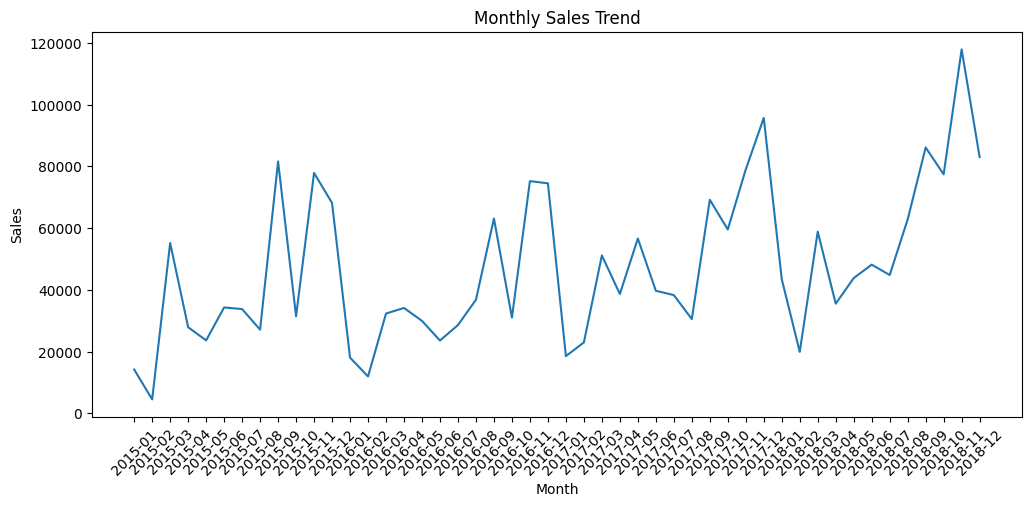

In [36]:
plt.figure(figsize=(12,5))

plt.plot(monthly_sales['Year_Month'].astype(str), monthly_sales['Sales'])

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.xticks(rotation=45)

plt.show()

##REGIONAL ANALYSIS

In [37]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

region_sales

,Sales
Region,
West,710219.6845
East,669518.7260
Central,492646.9132
South,389151.4590


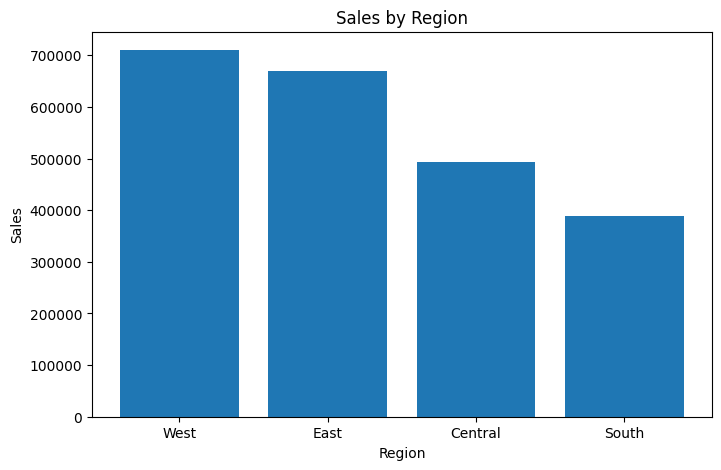

In [38]:
plt.figure(figsize=(8,5))

plt.bar(region_sales.index, region_sales.values)

plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales')

plt.show()

In [39]:
best_region = region_sales.idxmax()
best_region_sales = region_sales.max()

print("Best Region:", best_region)
print("Sales:", round(best_region_sales, 2))

Best Region: West
Sales: 710219.68


In [40]:
worst_region = region_sales.idxmin()
worst_region_sales = region_sales.min()

print("Worst Region:", worst_region)
print("Sales:", round(worst_region_sales, 2))

Worst Region: South
Sales: 389151.46


In [41]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

category_sales

,Sales
Category,
Technology,827455.8730
Furniture,728658.5757
Office Supplies,705422.3340


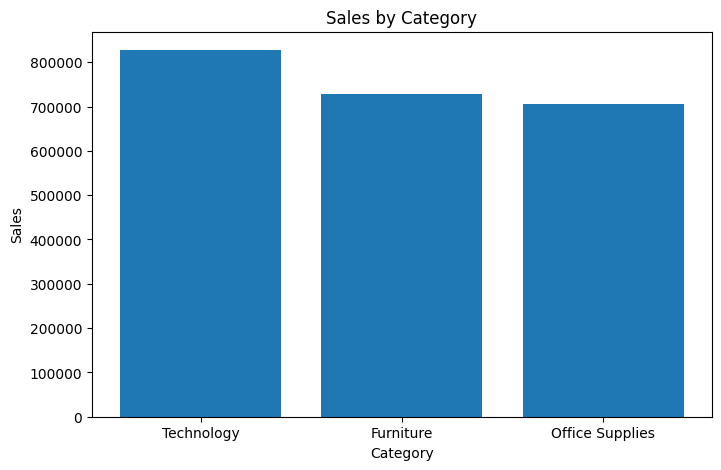

In [42]:
plt.figure(figsize=(8,5))

plt.bar(category_sales.index, category_sales.values)

plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales')

plt.show()

In [43]:
best_category = category_sales.idxmax()
best_category_sales = category_sales.max()

print("Best Category:", best_category)
print("Sales:", round(best_category_sales, 2))

Best Category: Technology
Sales: 827455.87


In [44]:
worst_category = category_sales.idxmin()
worst_category_sales = category_sales.min()

print("Worst Category:", worst_category)
print("Sales:", round(worst_category_sales, 2))

Worst Category: Office Supplies
Sales: 705422.33


In [45]:
subcategory_sales = df.groupby('Sub_Category')['Sales'].sum().sort_values(ascending=False)

subcategory_sales

,Sales
Sub_Category,
Phones,327782.4480
Chairs,322822.7310
Storage,219343.3920
Tables,202810.6280
Binders,200028.7850
Machines,189238.6310
Accessories,164186.7000
Copiers,146248.0940
Bookcases,113813.1987


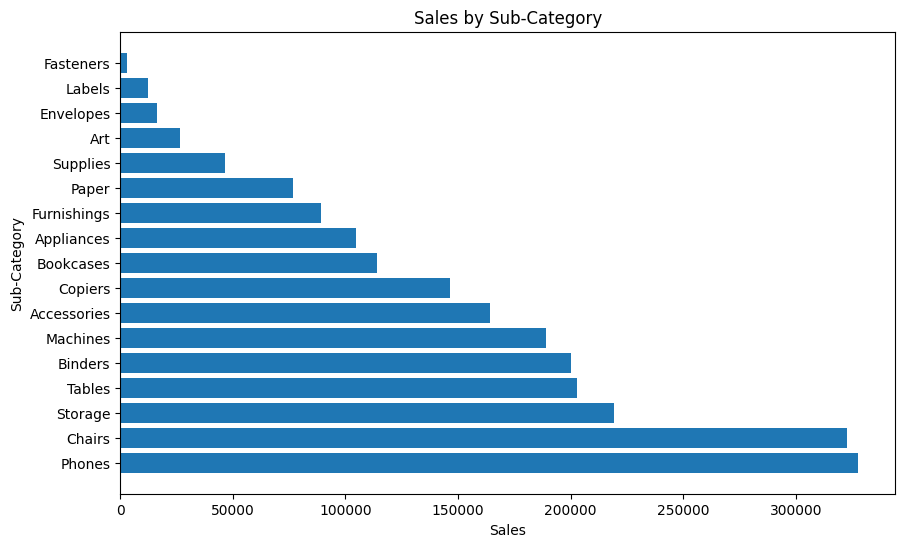

In [46]:
plt.figure(figsize=(10,6))

plt.barh(subcategory_sales.index, subcategory_sales.values)

plt.title('Sales by Sub-Category')
plt.xlabel('Sales')
plt.ylabel('Sub-Category')

plt.show()

In [47]:
best_subcategory = subcategory_sales.idxmax()
best_subcategory_sales = subcategory_sales.max()

print("Best Sub-Category:", best_subcategory)
print("Sales:", round(best_subcategory_sales, 2))

Best Sub-Category: Phones
Sales: 327782.45


In [48]:
worst_subcategory = subcategory_sales.idxmin()
worst_subcategory_sales = subcategory_sales.min()

print("Worst Sub-Category:", worst_subcategory)
print("Sales:", round(worst_subcategory_sales, 2))

Worst Sub-Category: Fasteners
Sales: 3001.96


##PRODUCT ANALYSIS

In [50]:
product_sales = df.groupby('Product_Name')['Sales'].sum().sort_values(ascending=False)

product_sales.head(10)

,Sales
Product_Name,
Canon imageCLASS 2200 Advanced Copier,61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480
HON 5400 Series Task Chairs for Big and Tall,21870.576
GBC DocuBind TL300 Electric Binding System,19823.479
GBC Ibimaster 500 Manual ProClick Binding System,19024.500
Hewlett Packard LaserJet 3310 Copier,18839.686
HP Designjet T520 Inkjet Large Format Printer - 24 Color,18374.895
GBC DocuBind P400 Electric Binding System,17965.068


In [51]:
top_10_products = product_sales.head(10)

top_10_products

,Sales
Product_Name,
Canon imageCLASS 2200 Advanced Copier,61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480
HON 5400 Series Task Chairs for Big and Tall,21870.576
GBC DocuBind TL300 Electric Binding System,19823.479
GBC Ibimaster 500 Manual ProClick Binding System,19024.500
Hewlett Packard LaserJet 3310 Copier,18839.686
HP Designjet T520 Inkjet Large Format Printer - 24 Color,18374.895
GBC DocuBind P400 Electric Binding System,17965.068


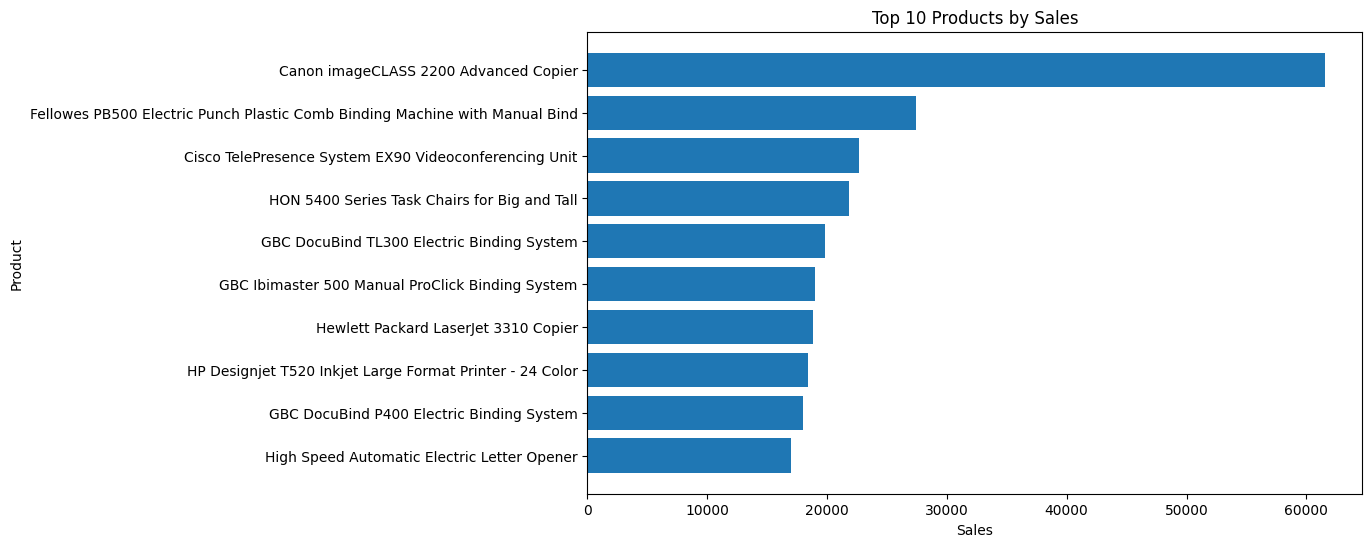

In [52]:
plt.figure(figsize=(10,6))

plt.barh(
    top_10_products.index[::-1],
    top_10_products.values[::-1]
)

plt.title('Top 10 Products by Sales')
plt.xlabel('Sales')
plt.ylabel('Product')

plt.show()

In [53]:
bottom_10_products = product_sales.tail(10).sort_values()

bottom_10_products

,Sales
Product_Name,
Eureka Disposable Bags for Sanitaire Vibra Groomer I Upright Vac,1.624
Avery 5,5.760
Xerox 20,6.480
Grip Seal Envelopes,7.072
Acme Serrated Blade Letter Opener,7.632
Avery Hi-Liter Pen Style Six-Color Fluorescent Set,7.700
"Avery Hi-Liter Comfort Grip Fluorescent Highlighter, Yellow Ink",7.800
Xerox 1989,7.968
4009 Highlighters,8.040


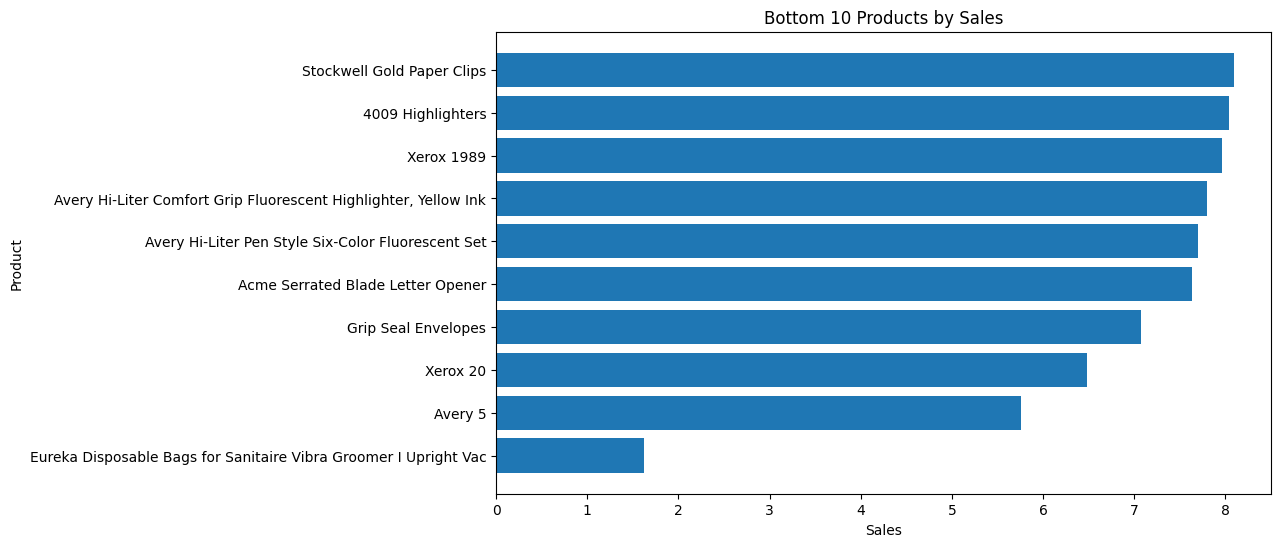

In [54]:
plt.figure(figsize=(10,6))

plt.barh(
    bottom_10_products.index,
    bottom_10_products.values
)

plt.title('Bottom 10 Products by Sales')
plt.xlabel('Sales')
plt.ylabel('Product')

plt.show()

##CUSTOMER SEGMENT ANALYSIS

In [55]:
segment_sales = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)

segment_sales

,Sales
Segment,
Consumer,1.148061e+06
Corporate,6.884941e+05
Home Office,4.249822e+05


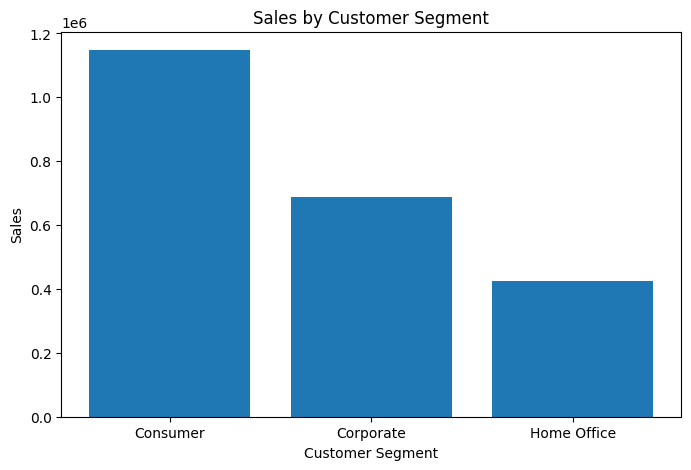

In [56]:
plt.figure(figsize=(8,5))

plt.bar(segment_sales.index, segment_sales.values)

plt.title('Sales by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Sales')

plt.show()

##SEASONALITY ANALYSIS

In [57]:
month_order = [
    'January',
    'February',
    'March',
    'April',
    'May',
    'June',
    'July',
    'August',
    'September',
    'October',
    'November',
    'December'
]

monthly_seasonality = df.groupby('Month_Name')['Sales'].sum()

monthly_seasonality = monthly_seasonality.reindex(month_order)

monthly_seasonality

,Sales
Month_Name,
January,94291.6296
February,59371.1154
March,197573.5872
April,136283.0006
May,154086.7237
June,145837.5233
July,145535.6890
August,157315.9270
September,300103.4117


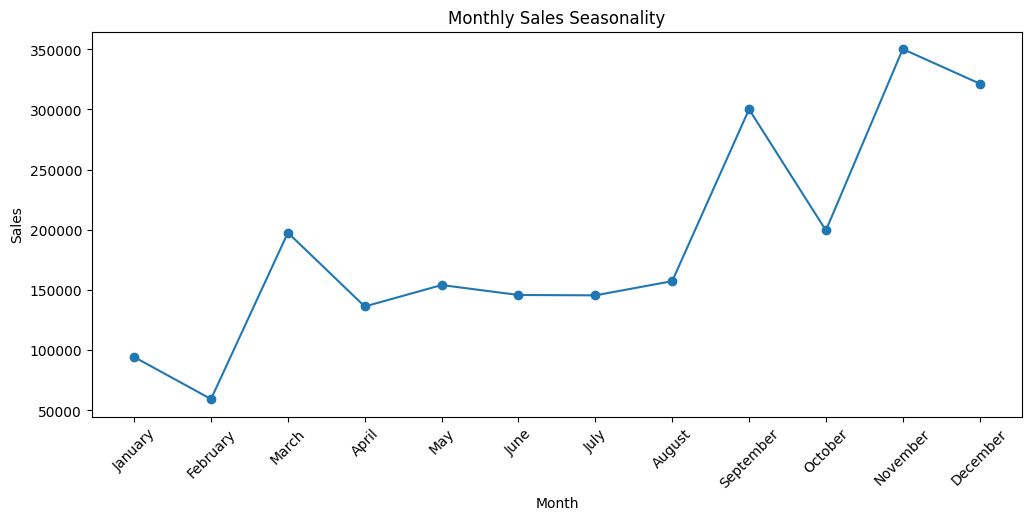

In [58]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_seasonality.index,
    monthly_seasonality.values,
    marker='o'
)

plt.title('Monthly Sales Seasonality')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.xticks(rotation=45)

plt.show()

In [59]:
best_month = monthly_seasonality.idxmax()
best_month_sales = monthly_seasonality.max()

print("Best Sales Month:", best_month)
print("Sales:", round(best_month_sales, 2))

Best Sales Month: November
Sales: 350161.71


In [60]:
worst_month = monthly_seasonality.idxmin()
worst_month_sales = monthly_seasonality.min()

print("Worst Sales Month:", worst_month)
print("Sales:", round(worst_month_sales, 2))

Worst Sales Month: February
Sales: 59371.12


In [61]:
quarterly_sales = df.groupby('Quarter')['Sales'].sum()

quarterly_sales

,Sales
Quarter,
1,351236.3322
2,436207.2476
3,602955.0277
4,871138.1752


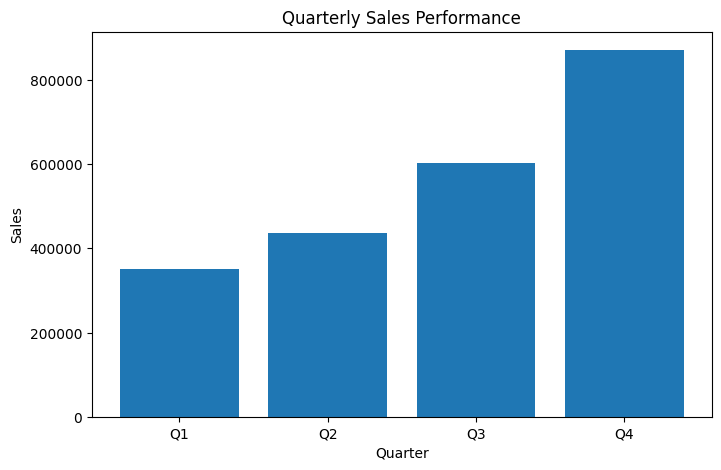

In [62]:
plt.figure(figsize=(8,5))

plt.bar(
    ['Q1', 'Q2', 'Q3', 'Q4'],
    quarterly_sales.values
)

plt.title('Quarterly Sales Performance')
plt.xlabel('Quarter')
plt.ylabel('Sales')

plt.show()

In [63]:
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False)

state_sales.head(10)

,Sales
State,
California,446306.4635
New York,306361.1470
Texas,168572.5322
Washington,135206.8500
Pennsylvania,116276.6500
Florida,88436.5320
Illinois,79236.5170
Michigan,76136.0740
Ohio,75130.3500


In [64]:
top_10_states = state_sales.head(10)

top_10_states

,Sales
State,
California,446306.4635
New York,306361.1470
Texas,168572.5322
Washington,135206.8500
Pennsylvania,116276.6500
Florida,88436.5320
Illinois,79236.5170
Michigan,76136.0740
Ohio,75130.3500


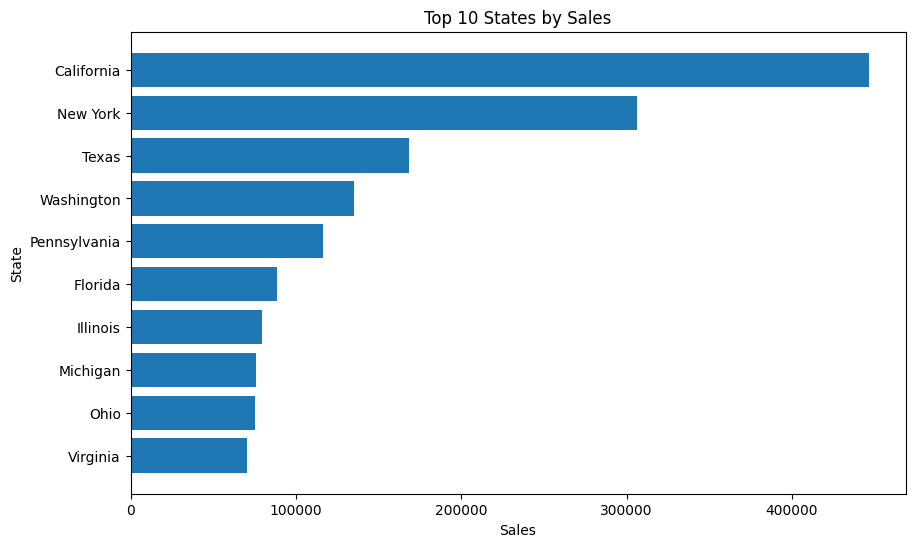

In [65]:
plt.figure(figsize=(10,6))

plt.barh(
    top_10_states.index[::-1],
    top_10_states.values[::-1]
)

plt.title('Top 10 States by Sales')
plt.xlabel('Sales')
plt.ylabel('State')

plt.show()

##ORDER ANALYSIS

In [66]:
region_orders = df.groupby('Region')['Order_ID'].nunique().sort_values(ascending=False)

region_orders

,Order_ID
Region,
West,1587
East,1369
Central,1156
South,810


In [67]:
region_aov = (
    df.groupby('Region')
    .agg(
        Revenue=('Sales', 'sum'),
        Orders=('Order_ID', 'nunique')
    )
)

region_aov['AOV'] = region_aov['Revenue'] / region_aov['Orders']

region_aov.sort_values('AOV', ascending=False)

,Revenue,Orders,AOV
Region,,,
East,669518.7260,1369,489.056776
South,389151.4590,810,480.433900
West,710219.6845,1587,447.523431
Central,492646.9132,1156,426.165150


##KPI Dashboard Table

In [68]:
kpis = {
    'Total Revenue': total_revenue,
    'Total Orders': total_orders,
    'Total Customers': total_customers,
    'Average Order Value': average_order_value,
    'Best Region': best_region,
    'Best Category': best_category,
    'Best Sub-Category': best_subcategory,
    'Best Sales Month': best_month
}

for key, value in kpis.items():
    print(key, ":", value)

Total Revenue : 2261536.7827000003
Total Orders : 4922
Total Customers : 793
Average Order Value : 459.4751691791955
Best Region : West
Best Category : Technology
Best Sub-Category : Phones
Best Sales Month : November


##Data Availability Check

In [69]:
if 'Profit' in df.columns:
    print("Profit data is available.")
else:
    print("Profit data is not available.")

Profit data is not available.


##Check Conversion Data

In [70]:
conversion_columns = [
    'Visitors',
    'Visits',
    'Leads',
    'Conversions',
    'Conversion_Rate'
]

available_conversion_columns = [
    column for column in conversion_columns if column in df.columns
]

print("Available conversion columns:", available_conversion_columns)

Available conversion columns: []


Final Business Insights

In [71]:
print("KEY BUSINESS FINDINGS")
print()
print("1. Best performing region:", best_region)
print("2. Lowest performing region:", worst_region)
print("3. Best performing category:", best_category)
print("4. Lowest performing category:", worst_category)
print("5. Best performing sub-category:", best_subcategory)
print("6. Lowest performing sub-category:", worst_subcategory)
print("7. Best sales month:", best_month)
print("8. Lowest sales month:", worst_month)

KEY BUSINESS FINDINGS

1. Best performing region: West
2. Lowest performing region: South
3. Best performing category: Technology
4. Lowest performing category: Office Supplies
5. Best performing sub-category: Phones
6. Lowest performing sub-category: Fasteners
7. Best sales month: November
8. Lowest sales month: February


In [72]:
print("===== FINAL RESULTS =====")
print()

print("Total Revenue:", round(total_revenue, 2))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Average Order Value:", round(average_order_value, 2))

print()

print("Best Region:", best_region)
print("Worst Region:", worst_region)

print()

print("Best Category:", best_category)
print("Worst Category:", worst_category)

print()

print("Best Sub-Category:", best_subcategory)
print("Worst Sub-Category:", worst_subcategory)

print()

print("Best Sales Month:", best_month)
print("Worst Sales Month:", worst_month)

print()

print("Top 10 Products:")
print(top_10_products)

print()

print("Bottom 10 Products:")
print(bottom_10_products)

===== FINAL RESULTS =====

Total Revenue: 2261536.78
Total Orders: 4922
Total Customers: 793
Average Order Value: 459.48

Best Region: West
Worst Region: South

Best Category: Technology
Worst Category: Office Supplies

Best Sub-Category: Phones
Worst Sub-Category: Fasteners

Best Sales Month: November
Worst Sales Month: February

Top 10 Products:
Product_Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T

##ACTIONABLE RECOMMENDATIONS FOR ALFIDO TECH

| Finding                                   | Tactical Recommendation                                                  |
| ----------------------------------------- | ------------------------------------------------------------------------ |
| West is the best region                   | Increase marketing and inventory investment in West                      |
| South is the worst region                 | Investigate low sales and run targeted promotions                        |
| Technology is the best category           | Increase stock and promotional efforts for Technology                    |
| Office Supplies is the weakest category   | Review pricing, demand, product mix and promotions                       |
| Phones are the best sub-category          | Maintain sufficient inventory and promote high-performing phone products |
| Fasteners are the weakest sub-category    | Consider discounts, bundles, or reducing inventory                       |
| November is the best month                | Prepare inventory and marketing campaigns before November                |
| February is the worst month               | Introduce seasonal discounts and promotional campaigns in February       |
| Top products generate high revenue        | Ensure consistent availability of top-performing products                |
| Bottom products generate very low revenue | Review whether to discount, bundle, replace, or discontinue them         |
